In [2]:
from lm_polygraph.utils import UEManager


# Load managers with_labels

base_path = '/nfs-stor/statml/maiya/managers_source_ue/final'

model='gemma12bit'

# model = 'llama8bit'
# model ='qwen14bit'
man_single = UEManager.load(f'{base_path}/single_{model}_no_embeddings.man')

man_multi = UEManager.load(f'{base_path}/multi_{model}_no_embeddings.man')

man_ambi = UEManager.load(f'{base_path}/ambi_{model}_no_embeddings.man')




{'obj': 'InitialStateCalculator'}
{'obj': 'RawInputCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'SemanticMatrixCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'GreedySemanticMatrixCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'ConcatGreedySemanticMatrixCalculator'}
{'obj': 'SemanticClassesCalculator'}
all_layers False
{'output_attentions': True, 'output_hidden_states': True, 'all_layers': True, 'obj': 'GreedyProbsCalculator'}
{'obj': 'EntropyCalculator'}
{'obj': 'GreedyLMProbsCalculator'}
{'obj': 'PromptCalculator'}
{'obj': 'SamplingGenerationCalculator'}
{'obj': 'BartScoreCalculator'}
{'obj': 'ModelScoreCalculator'}
{'obj': 'EnsembleTokenLevelDataCalculator'}
{'obj': 'PromptCalculator'}
{'obj': 'SamplingPromptCalculator'

In [46]:
managers = {
    'Ambiguous input': man_ambi,
    'Multi-answer':    man_multi,
    'Single answer':   man_single,
}


In [47]:
from collections import defaultdict
from types import SimpleNamespace

# managers = { 'Ambiguous input': man_ambi, 'Multi-answer': man_multi, 'Single answer': man_single }

# create an empty combined manager-like object
combined = SimpleNamespace(
    stats={},
    estimations=defaultdict(list),
    metrics=defaultdict(list),
    gen_metrics=defaultdict(list),
)

for scenario_name, man in managers.items():
    # ---- stats ----
    for key, value in man.stats.items():
        if isinstance(value, list):
            
            # per-generation list -> concatenate
            combined.stats.setdefault(key, []).extend(value)
        else:
            # scalar/statistic -> store per scenario
            combined.stats.setdefault(key, {})[scenario_name] = value

    # add scenario label per generation (based on labels length)
    n = len(man.stats["labels"])
    combined.stats.setdefault("scenario", []).extend([scenario_name] * n)

    # ---- estimations ----
    for key, values in man.estimations.items():         # key is ('sequence', method)
        combined.estimations[key].extend(values)

    # ---- metrics ----
    for key, value in man.metrics.items():
        if isinstance(value, list):
            combined.metrics[key].extend(value)
        else:
            combined.metrics.setdefault(key, {})[scenario_name] = value

    # ---- gen_metrics ----
    for key, value in man.gen_metrics.items():
        if isinstance(value, list):
            combined.gen_metrics[key].extend(value)
        else:
            combined.gen_metrics.setdefault(key, {})[scenario_name] = value


In [48]:
from collections import defaultdict
from types import SimpleNamespace

managers_single_ambi = { 'Ambiguous input': man_ambi, 'Single answer': man_single }

# create an empty combined manager-like object
single_ambi = SimpleNamespace(
    stats={},
    estimations=defaultdict(list),
    metrics=defaultdict(list),
    gen_metrics=defaultdict(list),
)

for scenario_name, man in managers_single_ambi.items():
    # ---- stats ----
    for key, value in man.stats.items():
        if isinstance(value, list):
            
            # per-generation list -> concatenate
            single_ambi.stats.setdefault(key, []).extend(value)
        else:
            # scalar/statistic -> store per scenario
            single_ambi.stats.setdefault(key, {})[scenario_name] = value

    # add scenario label per generation (based on labels length)
    n = len(man.stats["labels"])
    single_ambi.stats.setdefault("scenario", []).extend([scenario_name] * n)

    # ---- estimations ----
    for key, values in man.estimations.items():         # key is ('sequence', method)
        single_ambi.estimations[key].extend(values)

    # ---- metrics ----
    for key, value in man.metrics.items():
        if isinstance(value, list):
            single_ambi.metrics[key].extend(value)
        else:
            single_ambi.metrics.setdefault(key, {})[scenario_name] = value

    # ---- gen_metrics ----
    for key, value in man.gen_metrics.items():
        if isinstance(value, list):
            single_ambi.gen_metrics[key].extend(value)
        else:
            single_ambi.gen_metrics.setdefault(key, {})[scenario_name] = value


In [49]:
import copy

order = ['Ambiguous input', 'Multi-answer', 'Single answer']

base_name = order[0]
combined = copy.deepcopy(managers[base_name])  # start from first manager

n_base = len(combined.stats["labels"])
combined.stats["scenario"] = [base_name] * n_base  # per-generation scenario label
def ensure_scenario_dict(stats_or_metrics, key, scenario_name):
    """Turn a scalar value into {scenario_name: value} if needed."""
    val = stats_or_metrics.get(key)
    if isinstance(val, dict):
        return
    stats_or_metrics[key] = {scenario_name: val}

for k, v in list(combined.stats.items()):
    if not isinstance(v, list) and k != "scenario":
        ensure_scenario_dict(combined.stats, k, base_name)

for k, v in list(combined.metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(combined.metrics, k, base_name)

for k, v in list(combined.gen_metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(combined.gen_metrics, k, base_name)

def append_manager(combined, other, other_name):
    # --- stats ---
    n_other = len(other.stats["labels"])
    combined.stats["scenario"].extend([other_name] * n_other)

    for key, val in other.stats.items():
        if key == "scenario":
            continue
        if isinstance(val, list):
            combined.stats.setdefault(key, [])
            combined.stats[key].extend(val)
        else:
            # per-scenario scalar
            ensure_scenario_dict(combined.stats, key, other_name)
            combined.stats[key][other_name] = val

    # --- estimations ---
    for key, vals in other.estimations.items():  # key is ('sequence', method)
        combined.estimations.setdefault(key, [])
        combined.estimations[key].extend(vals)

    # --- metrics ---
    for key, val in other.metrics.items():
        if isinstance(val, list):
            combined.metrics.setdefault(key, [])
            combined.metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.metrics, key, other_name)
            combined.metrics[key][other_name] = val

    # --- gen_metrics ---
    for key, val in other.gen_metrics.items():
        if isinstance(val, list):
            combined.gen_metrics.setdefault(key, [])
            combined.gen_metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.gen_metrics, key, other_name)
            combined.gen_metrics[key][other_name] = val
for name in order[1:]:
    append_manager(combined, managers[name], name)


In [50]:
import copy

order = ['Ambiguous input','Single answer']

base_name = order[0]
single_ambi = copy.deepcopy(managers_single_ambi[base_name])  # start from first manager

n_base = len(single_ambi.stats["labels"])
single_ambi.stats["scenario"] = [base_name] * n_base  # per-generation scenario label
def ensure_scenario_dict(stats_or_metrics, key, scenario_name):
    """Turn a scalar value into {scenario_name: value} if needed."""
    val = stats_or_metrics.get(key)
    if isinstance(val, dict):
        return
    stats_or_metrics[key] = {scenario_name: val}

for k, v in list(single_ambi.stats.items()):
    if not isinstance(v, list) and k != "scenario":
        ensure_scenario_dict(single_ambi.stats, k, base_name)

for k, v in list(single_ambi.metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(single_ambi.metrics, k, base_name)

for k, v in list(single_ambi.gen_metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(single_ambi.gen_metrics, k, base_name)

def append_manager(single_ambi, other, other_name):
    # --- stats ---
    n_other = len(other.stats["labels"])
    single_ambi.stats["scenario"].extend([other_name] * n_other)

    for key, val in other.stats.items():
        if key == "scenario":
            continue
        if isinstance(val, list):
            single_ambi.stats.setdefault(key, [])
            single_ambi.stats[key].extend(val)
        else:
            # per-scenario scalar
            ensure_scenario_dict(combined.stats, key, other_name)
            single_ambi.stats[key][other_name] = val

    # --- estimations ---
    for key, vals in other.estimations.items():  # key is ('sequence', method)
        single_ambi.estimations.setdefault(key, [])
        single_ambi.estimations[key].extend(vals)

    # --- metrics ---
    # for key, val in other.metrics.items():
    #     if isinstance(val, list):
    #         single_ambi.metrics.setdefault(key, [])
    #         single_ambi.metrics[key].extend(val)
    #     else:
    #         ensure_scenario_dict(combined.metrics, key, other_name)
    #         single_ambi.metrics[key][other_name] = val

    # --- gen_metrics ---
    for key, val in other.gen_metrics.items():
        if isinstance(val, list):
            single_ambi.gen_metrics.setdefault(key, [])
            single_ambi.gen_metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.gen_metrics, key, other_name)
            single_ambi.gen_metrics[key][other_name] = val
for name in order[1:]:
    append_manager(single_ambi, managers_single_ambi[name], name)


In [51]:
from lm_polygraph.ue_metrics import PredictionRejectionArea

ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
combined.ue_metrics =ue_metrics
combined.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [52]:
from lm_polygraph.ue_metrics import PredictionRejectionArea

ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
single_ambi.ue_metrics =ue_metrics
single_ambi.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [53]:
man_single.ue_metrics =ue_metrics
man_single.eval_ue()

man_multi.ue_metrics =ue_metrics
man_multi.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [41]:
import numpy as np
from scipy.stats import spearmanr

def bootstrap_corr_diff(x1, y1, x2, y2, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    n1 = len(x1)
    n2 = len(x2)

    # observed correlations
    rho1, _ = spearmanr(x1, y1)
    rho2, _ = spearmanr(x2, y2)
    obs_diff = rho1 - rho2

    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):
        idx1 = rng.integers(0, n1, n1)
        idx2 = rng.integers(0, n2, n2)

        r1, _ = spearmanr(x1[idx1], y1[idx1])
        r2, _ = spearmanr(x2[idx2], y2[idx2])

        boot_diffs[i] = r1 - r2

    # two-sided p-value
    p_value = np.mean(np.abs(boot_diffs) >= np.abs(obs_diff))

    # confidence interval
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    return {
        "rho_1": rho1,
        "rho_2": rho2,
        "delta_rho": obs_diff,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }
data = {}

managers = {
    "combined": combined,
    "multi": man_multi,
    "single": man_single,
    "single_ambi": single_ambi,
}

for scenario_name, mgr in managers.items():
    decision = 1 - np.asarray(mgr.gen_metrics[('sequence', 'decision')])

    for method_name, est_values in mgr.estimations.items():
        est_values = np.asarray(est_values)

        n = min(len(decision), len(est_values))
        d = decision[:n]
        e = est_values[:n]

        mask = ~(np.isnan(d) | np.isnan(e))
        if mask.sum() < 5:
            continue

        key = (scenario_name, method_name[1])
        data[key] = {
            "uncertainty": e[mask],
            "quality": d[mask],
        }


from itertools import combinations

scenarios = list(managers.keys())

scenario_pairs = list(combinations(scenarios, 2))

import pandas as pd

rows = []

methods = sorted({k[1] for k in data.keys()})

for method in methods:
    for s1, s2 in scenario_pairs:
        key1 = (s1, method)
        key2 = (s2, method)

        if key1 not in data or key2 not in data:
            continue

        res = bootstrap_corr_diff(
            data[key1]["uncertainty"],
            data[key1]["quality"],
            data[key2]["uncertainty"],
            data[key2]["quality"],
            n_boot=5000,
        )

        rows.append({
            "method": method,
            "scenario_1": s1,
            "scenario_2": s2,
            "rho_1": res["rho_1"],
            "rho_2": res["rho_2"],
            "delta_rho": res["delta_rho"],
            "p_value": res["p_value"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
        })


/tmp/ipykernel_1314561/428517590.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho1, _ = spearmanr(x1, y1)
/tmp/ipykernel_1314561/428517590.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho2, _ = spearmanr(x2, y2)
/tmp/ipykernel_1314561/428517590.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r1, _ = spearmanr(x1[idx1], y1[idx1])
/tmp/ipykernel_1314561/428517590.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(x2[idx2], y2[idx2])


KeyboardInterrupt: 

In [9]:
df_pvals = pd.DataFrame(rows)
df_pvals.to_csv(f"results/{model}_bootstrap_corr_diff_all_pairs.csv", index=False)


In [54]:
import numpy as np
from scipy.stats import spearmanr
import pandas as pd

# Assume these are already defined:
# combined, man_multi, man_single, single_ambi

managers = {
    "combined": combined,
    "multi": man_multi,
    "single": man_single,
    "single_ambi": single_ambi,
}

rows = []

for scenario_name, mgr in managers.items():
    # quality / decision scores
    decision = 1- np.asarray(mgr.gen_metrics[('sequence', 'decision')])
    for method_name, est_values in mgr.estimations.items():
        est_values = np.asarray(est_values)

        # Optional: handle length mismatch or NaNs robustly
        n = min(len(decision), len(est_values))
        d = decision[:n]
        e = est_values[:n]

        mask = ~(np.isnan(d) | np.isnan(e))
        if mask.sum() < 2:
            # not enough valid points for correlation
            continue

        rho, _ = spearmanr(e[mask], d[mask])

        rows.append({
            "scenario": scenario_name,
            "method": method_name[1],
            "spearman": rho,
        })

# Build a single DataFrame and save
df = pd.DataFrame(rows)
df.to_csv(f"results/{model}_spearman_results_new.csv", index=False)

print(df.head())


   scenario                          method  spearman
0  combined      MaximumSequenceProbability  0.326717
1  combined                      Perplexity  0.296975
2  combined                MeanTokenEntropy  0.325731
3  combined  MeanPointwiseMutualInformation  0.169396
4  combined                   SelfCertainty  0.341881


/tmp/ipykernel_1314561/4014739569.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(e[mask], d[mask])


In [21]:
man_single.gen_metrics[('sequence', 'decision')]

[]

In [10]:
import pandas as pd

# ---------- 1. Load and pivot each model ----------

def load_model_table(csv_path: str, model_label: str):
    """
    csv_path: path to CSV with columns [method, prr, type]
    model_label: label used in column MultiIndex (e.g. 'llama', 'mistral')
    """
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="scenario", values="spearman")

    # desired types, including single_ambi
    desired_types = ["single", "single_ambi", "multi", "combined"]
    # use reindex so it works even if some types are missing in this file
    wide = wide.reindex(columns=desired_types)

    # MultiIndex columns: (model_label, type)
    wide.columns = pd.MultiIndex.from_product(
        [[model_label], desired_types]
    )
    return wide

# Example usage: replace paths + labels as needed
t_llama = load_model_table("results/llama8bit_spearman_results_new.csv", "llama8bit")
t_gemma = load_model_table("results/gemma12bit_spearman_results_new.csv", "gemma12bit")
t_qwen  = load_model_table("results/qwen14bit_spearman_results_new.csv",      "qwen14bit")

# ---------- 2. Combine side-by-side on 'method' ----------

combined = pd.concat([t_llama, t_gemma, t_qwen], axis=1)

# Optional: enforce metric order if you have one
metric_order = [
    "MaximumSequenceProbability",
    "Perplexity",
    "MeanTokenEntropy",
    "MeanPointwiseMutualInformation",
    # "MeanConditionalPointwiseMutualInformation",
    "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy",
    # "ToeknSAR",

    "Consistency",
    # "NLIConsistency",
    "NumSemSets",
    "EigValLaplacian_NLI_score_entail",
    # "EigValLaplacian_NLI_score_contra",
    "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail",
    # "DegMat_NLI_score_contra",
    "Eccentricity_NLI_score_entail",
    # "Eccentricity_NLI_score_contra",

    "SemanticEntropy",
    "LUQ",
    "SAR",
    "SemanticDensity",
    "CocoaMSP",
    "CocoaPPL",
    "CocoaMTE",
    # "NLICocoaMSP",
    # "NLICocoaPPL",
    # "NLICocoaMTE",

    # "CCP",
    # "TokenSAR",
    "PTrue",
    'UEVerbalized2S'
]
metric_pretty_name = {
    "MaximumSequenceProbability": "SP",
    "Perplexity": "PPL",
    "MeanTokenEntropy": "MTE",
    "MeanPointwiseMutualInformation": "MPMI",
    "MeanConditionalPointwiseMutualInformation": "MCPMI",
    "MonteCarloSequenceEntropy": "MCSE",
    "MonteCarloNormalizedSequenceEntropy": "MCNSE",
    "ToeknSAR": "TokenSAR",

    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail": r"$\text{EigValLaplacian}_{entail}$",
    "EigValLaplacian_NLI_score_contra": r"$\text{EigValLaplacian}_{contra}$",
    "EigValLaplacian_Jaccard_score": r"$\text{EigValLaplacian}_{Jaccard}$",
    "DegMat_NLI_score_entail": r"$\text{DegMat}_{entail}$",
    "DegMat_NLI_score_contra": r"$\text{DegMat}_{contra}$",
    "Eccentricity_NLI_score_entail": r"$\text{Eccentricity}_{entail}$",
    "Eccentricity_NLI_score_contra": r"$\text{Eccentricity}_{contra}$",

    "Consistency": "Consistency",
    "SemanticEntropy": "Semantic Entropy",
    "LUQ": "LUQ",
    "SAR": "SAR",
    "SemanticDensity": "Semantic Density",
    "CocoaMSP": "CocoaMSP",
    "CocoaPPL": "CocoaPPL",
    "CocoaMTE": "CocoaMTE",

    "CCP": "CCP",
    "PTrue": "P(True)",
    "UEVerbalized2S":"Verbalized-2S"
}

combined = combined.reindex(metric_order).dropna(how="all")

# models + types in order
models = ["llama8bit", "gemma12bit", "qwen14bit"]
types = ["single", "single_ambi", "multi", "combined"]


# ---------- 3. (Optional) escape LaTeX specials in metric names ----------

def latex_escape(s: str) -> str:
    return (
        s.replace("\\", r"\textbackslash{}")
         .replace("_", r"\_")
         .replace("%", r"\%")
         .replace("&", r"\&")
         .replace("#", r"\#")
         .replace("{", r"\{")
         .replace("}", r"\}")
    )


# ---------- 4. Format best (bold) and second-best (underline) per column ----------
# Also: if a model doesn't have a value for a type, show '---'.

formatted = combined.copy().astype(object)  # make room for strings

for col in formatted.columns:  # col is like ('llama8bit', 'single')
    s = combined[col]
    s_nonan = s.dropna()

    # No non-NaN values at all in this column → everything becomes '---'
    if len(s_nonan) == 0:
        for idx in combined.index:
            formatted.loc[idx, col] = r"---"
        continue

    best_idx = s_nonan.idxmax()
    second_idx = s_nonan.drop(best_idx).idxmax() if len(s_nonan) > 1 else None

    for idx in combined.index:
        val = combined.loc[idx, col]
        if pd.isna(val):
            # Missing in this model/type → '---'
            formatted.loc[idx, col] = r"---"
            continue

        txt = f"{val:.3f}"
        if idx == best_idx:
            formatted.loc[idx, col] = rf"\textbf{{{txt}}}"
        elif second_idx is not None and idx == second_idx:
            formatted.loc[idx, col] = rf"\underline{{{txt}}}"
        else:
            formatted.loc[idx, col] = txt


# ---------- 5. Build LaTeX body rows ----------

rows = []
for metric, row in formatted.iterrows():   # use formatted, not combined
    # skip rows that are entirely missing (shouldn't happen after dropna(how="all"))
    if all((str(x) == "nan" for x in row)):
        continue

    metric_name = metric_pretty_name[metric]
    cells = [metric_name]
    for m in models:
        for t in types:
            cell = row[(m, t)]
            cells.append(str(cell))
    rows.append(" & ".join(cells) + r" \\")
body = "\n".join(rows)


# ---------- 6. Build the LaTeX header with multicolumns per model ----------

# column spec: 1 metric column + 4 per model
colspec = "l" + "cccc" * len(models)

# model names in header
model_headers = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen14bit": "Qwen-14b-it"
}

header_line1_parts = [r"\textbf{Metric}"]
for m in models:
    model_tex = model_headers[m]
    part = f"\\multicolumn{{4}}{{c}}{{\\textbf{{{model_tex}}}}}"
    header_line1_parts.append(part)
header_line1 = " & ".join(header_line1_parts) + r" \\"

# cmidrule lines: 4 columns per model block
cmidrules = []
col_start = 2  # first model block starts at column 2
for _ in models:
    col_end = col_start + 3  # 4 columns total
    cmidrules.append(f"\\cmidrule(lr){{{col_start}-{col_end}}}")
    col_start = col_end + 1
cmidrule_line = " ".join(cmidrules)

# second header line: metric column is empty, then types for each model
second_header_cells = [""]
for _ in models:
    second_header_cells.extend([
        r"\textbf{single}",
        r"\textbf{ambi}",
        r"\textbf{multi}",
        r"\textbf{combined}",
    ])
second_header_line = " & ".join(second_header_cells) + r" \\"


# ---------- 7. Put everything together ----------

latex_table = (
    f"\\begin{{tabular}}{{{colspec}}}\n"
    "\\toprule\n"
    + header_line1 + "\n"
    + cmidrule_line + "\n"
    + second_header_line + "\n"
    "\\midrule\n"
    + body + "\n"
    "\\bottomrule\n"
    "\\end{tabular}"
)

print(latex_table)


\begin{tabular}{lcccccccccccc}
\toprule
\textbf{Metric} & \multicolumn{4}{c}{\textbf{Llama-8b-it}} & \multicolumn{4}{c}{\textbf{Gemma-12b-it}} & \multicolumn{4}{c}{\textbf{Qwen-14b-it}} \\
\cmidrule(lr){2-5} \cmidrule(lr){6-9} \cmidrule(lr){10-13}
 & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} \\
\midrule
SP & 0.476 & 0.448 & 0.426 & 0.457 & 0.446 & 0.345 & 0.325 & 0.327 & 0.450 & 0.352 & 0.427 & 0.366 \\
PPL & 0.405 & 0.400 & 0.325 & 0.384 & 0.428 & 0.314 & 0.323 & 0.297 & 0.458 & 0.351 & 0.404 & 0.345 \\
MTE & 0.452 & 0.450 & 0.385 & 0.446 & 0.473 & 0.341 & 0.366 & 0.326 & 0.478 & 0.375 & 0.432 & 0.375 \\
MPMI & 0.278 & 0.170 & 0.285 & 0.246 & 0.133 & 0.184 & 0.093 & 0.169 & -0.055 & 0.042 & -0.012 & 0.038 \\
MCSE & 0.493 & 0.466 & \underline{0.463} & \underline{0.493} & 0.473 & 0.368 & 0.341 & 0.348 & 0.431 & 0.339 & 0

In [15]:
# average over models
avg = combined.groupby(level=1, axis=1).mean()
std = combined.groupby(level=1, axis=1).std()

# Average over models: (metric × (model, type)) → (metric × type)
avg = combined.groupby(level=1, axis=1).mean()

# Enforce column order explicitly
avg = avg.reindex(columns=types)


# avg columns: ['single', 'single_ambi', 'multi', 'combined']


/tmp/ipykernel_3371464/409911335.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  avg = combined.groupby(level=1, axis=1).mean()
/tmp/ipykernel_3371464/409911335.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std = combined.groupby(level=1, axis=1).std()
/tmp/ipykernel_3371464/409911335.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  avg = combined.groupby(level=1, axis=1).mean()


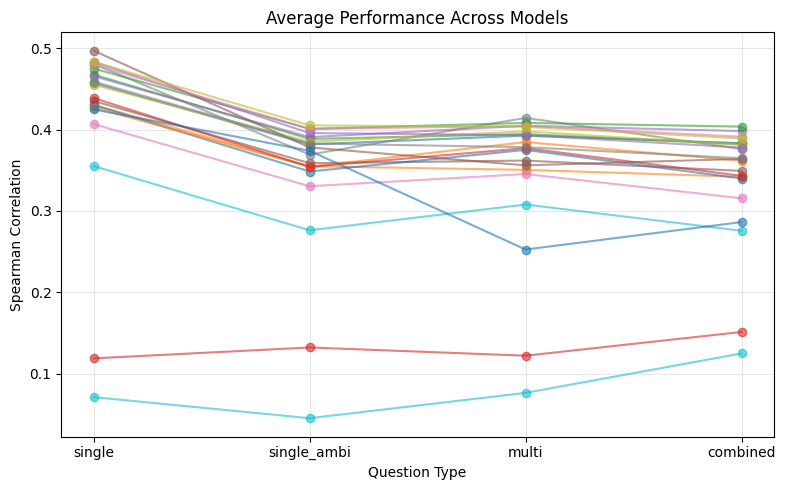

In [16]:
import matplotlib.pyplot as plt

types = ["single", "single_ambi", "multi", "combined"]

plt.figure(figsize=(8, 5))

for metric in avg.index:
    plt.plot(types, avg.loc[metric, types], marker="o", alpha=0.6)

plt.xlabel("Question Type")
plt.ylabel("Spearman Correlation")
plt.title("Average Performance Across Models")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


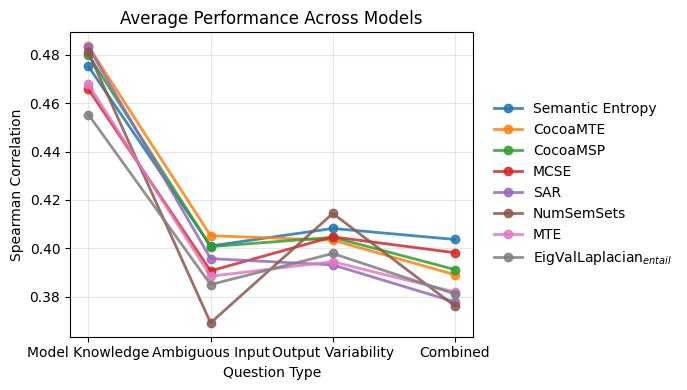

In [17]:
import matplotlib.pyplot as plt

types = ["single", "single_ambi", "multi", "combined"]
type_labels = ["Model Knowledge", "Ambiguous Input", "Output Variability", "Combined"]

plt.figure(figsize=(7, 4))


k = 8
selected_metrics = (
    avg.mean(axis=1)
       .sort_values(ascending=False)
       .head(k)
       .index
       .tolist()
)

for metric in selected_metrics:
    plt.plot(
        type_labels,
        avg.loc[metric, types],
        marker="o",
        linewidth=2,
        alpha=0.85,
        label=metric_pretty_name.get(metric, metric),
    )

plt.xlabel("Question Type")
plt.ylabel("Spearman Correlation")
plt.title("Average Performance Across Models")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:


metric_groups = {
    "TokenProb": [
        "MaximumSequenceProbability",
        "Perplexity",
        "MeanTokenEntropy",
        "MeanPointwiseMutualInformation",
        "MonteCarloSequenceEntropy",
        "MonteCarloNormalizedSequenceEntropy",
    ],
    "Consistency": [
        "Consistency",
        "NumSemSets",
        "EigValLaplacian_NLI_score_entail",
        "EigValLaplacian_Jaccard_score",
        "DegMat_NLI_score_entail",
        "Eccentricity_NLI_score_entail",
    ],
    "Hybrid": [
        "SemanticEntropy",
        "LUQ",
        "SAR",
        "SemanticDensity",
        "CocoaMSP",
        "CocoaPPL",
        "CocoaMTE",
    ],
    "Verbalized": [
                "PTrue",
        "UEVerbalized2S",
    ]
}


# avg: index = metric, columns = question types
# e.g., avg = combined.groupby(level=1, axis=1).mean()

best_metrics = {}

for group, metrics in metric_groups.items():
    available = [m for m in metrics if m in avg.index]
    if not available:
        continue

    scores = avg.loc[available].mean(axis=1)  # avg over question types
    best_metrics[group] = scores.idxmax()
print(best_metrics)
# {
#   'TokenProb': 'MonteCarloNormalizedSequenceEntropy',
#   'Consistency': 'EigValLaplacian_NLI_score_entail',
#   'Hybrid': 'SemanticEntropy'
# }


{'TokenProb': 'MonteCarloSequenceEntropy', 'Consistency': 'NumSemSets', 'Hybrid': 'SemanticEntropy', 'Verbalized': 'UEVerbalized2S'}


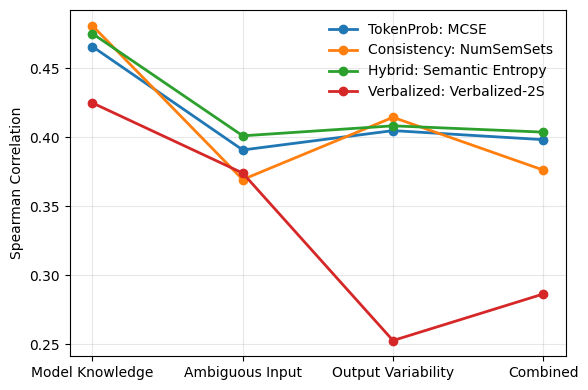

In [28]:
plt.figure(figsize=(6, 4))

for group, metric in best_metrics.items():
    plt.plot(
        ["Model Knowledge", "Ambiguous Input", "Output Variability", "Combined"],
        avg.loc[metric],
        marker="o",
        linewidth=2,
        label=f"{group}: {metric_pretty_name.get(metric, metric)}",
    )

# plt.xlabel("Question Type")
plt.ylabel("Spearman Correlation")
# plt.title("Best Metric per Family (Averaged Across Models)")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


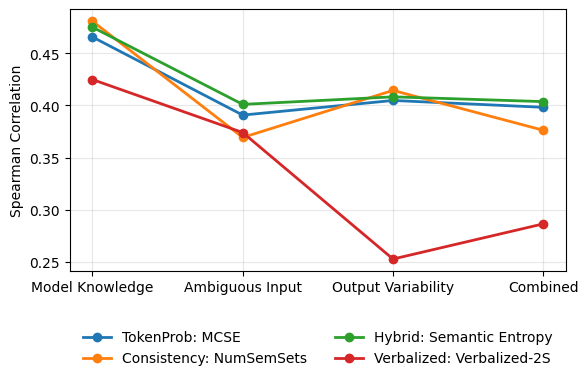

In [32]:
plt.figure(figsize=(6, 4))

for group, metric in best_metrics.items():
    plt.plot(
        ["Model Knowledge", "Ambiguous Input", "Output Variability", "Combined"],
        avg.loc[metric],
        marker="o",
        linewidth=2,
        label=f"{group}: {metric_pretty_name.get(metric, metric)}",
    )

plt.ylabel("Spearman Correlation")
plt.grid(alpha=0.3)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.savefig('correlations.pdf')
plt.show()


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

types = ["single", "single_ambi", "multi", "combined"]
type_labels = ["Model Knowledge", "Ambiguous Input", "Output Variability", "Combined"]

# order rows by group for nicer display
rows = []
row_labels = []
for group, metric in best_metrics.items():
    if metric not in avg.index:
        continue
    rows.append(avg.loc[metric, types].values)
    # label rows as "Group: PrettyName"
    pretty = metric_pretty_name.get(metric, metric)
    row_labels.append(f"{group}")

import numpy as np
heat_data = np.vstack(rows)

# Put into a DataFrame for seaborn
import pandas as pd
df_heat = pd.DataFrame(heat_data, index=row_labels, columns=type_labels)


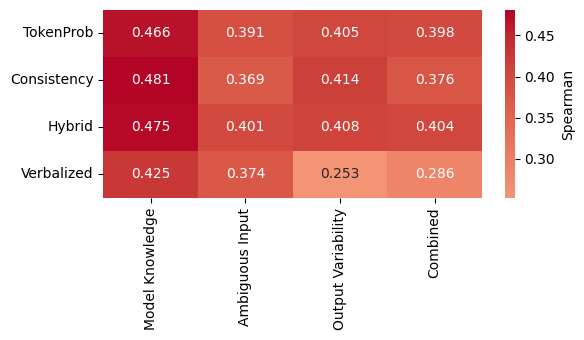

In [44]:
plt.figure(figsize=(6, 3.5))

sns.heatmap(
    df_heat,
    annot=True,           # show numbers in cells
    fmt=".3f",
    cmap="coolwarm",
    center=0,             # optional: center at 0
    cbar_kws={"label": "Spearman"},
)

plt.ylabel("")  # row labels already descriptive
plt.xlabel("")  # columns already descriptive
# plt.title("Best Metric per Family (Averaged Across Models)")
plt.tight_layout()
plt.savefig('correlations.pdf')
plt.show()


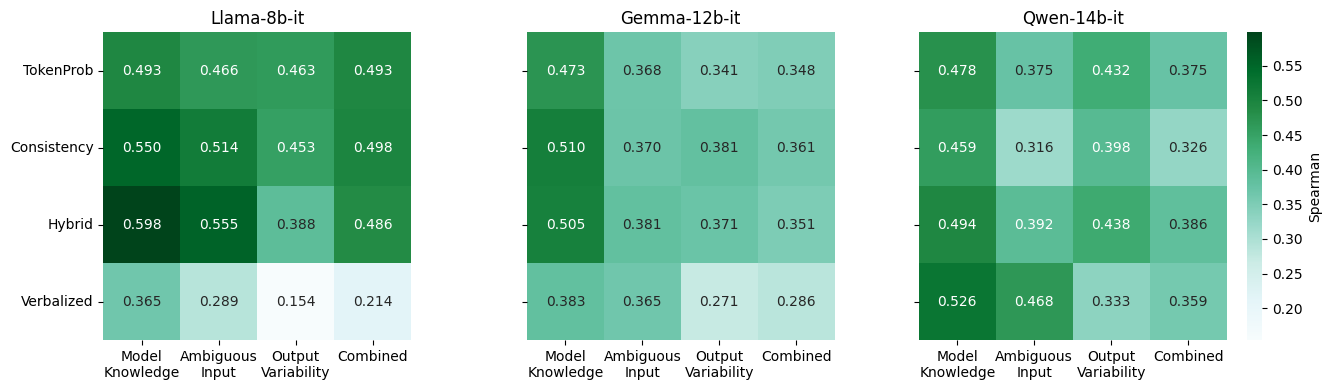

In [62]:
types = ["single", "single_ambi", "multi", "combined"]
type_labels = [
    "Model\nKnowledge",
    "Ambiguous\nInput",
    "Output\nVariability",
    "Combined",
]

models = ["llama8bit", "gemma12bit", "qwen14bit"]
model_pretty = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen14bit": "Qwen-14b-it",
}
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    1, len(models),
    figsize=(14, 4),
    sharey=True,
)

# Optional: compute global min/max for consistent color scale
all_vals = []

for m in models:
    per_model = combined.xs(m, axis=1, level=0).reindex(columns=types)

    for metric in best_metrics_per_model[m].values():
        all_vals.extend(per_model.loc[metric, types].values)

vmin = min(all_vals)
vmax = max(all_vals)

for ax, m in zip(axes, models):
    per_model = combined.xs(m, axis=1, level=0).reindex(columns=types)

    rows = []
    row_labels = []

    for group, metric in best_metrics_per_model[m].items():
        if metric not in per_model.index:
            continue

        rows.append(per_model.loc[metric, types].values)
        pretty = metric_pretty_name.get(metric, metric)
        row_labels.append(f"{group}")

    heat_df = pd.DataFrame(
        np.vstack(rows),
        index=row_labels,
        columns=type_labels,
    )

    sns.heatmap(
        heat_df,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="BuGn",
        vmin=vmin,
        vmax=vmax,
        cbar=ax is axes[-1],  # only last plot gets colorbar
        cbar_kws={"label": "Spearman"} if ax is axes[-1] else None,
    )

    ax.set_title(model_pretty.get(m, m))
    ax.set_xticklabels(type_labels, rotation=0, ha="center")
    ax.set_aspect("equal")

    ax.set_xlabel("")
    ax.set_ylabel("")

# plt.suptitle(
#     "Best Method per Family for Each Model",
#     y=1.05,
#     fontsize=12,
# )
plt.tight_layout()
plt.savefig('correlations.pdf')
plt.show()


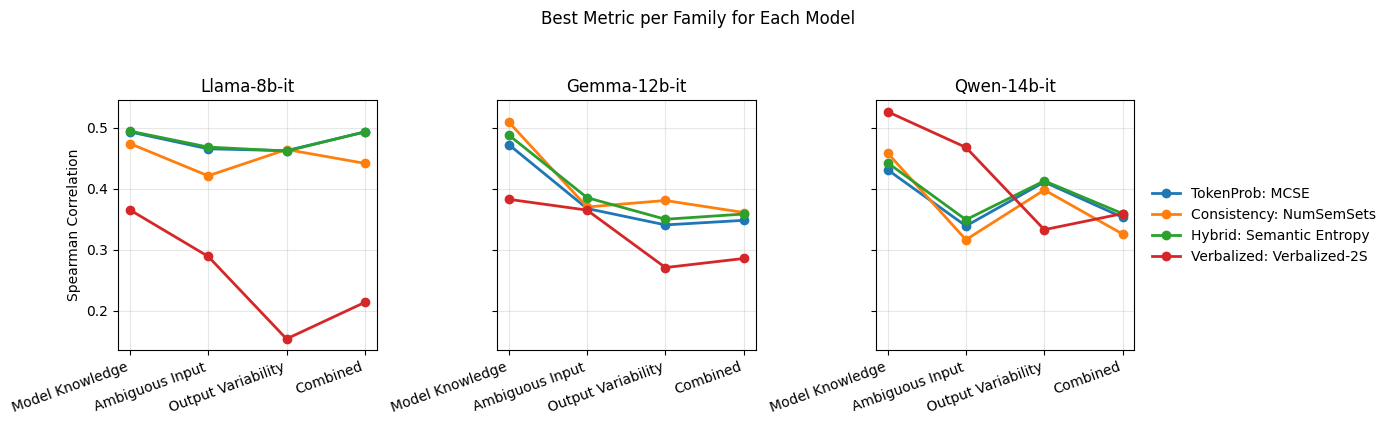

In [21]:
types = ["single", "single_ambi", "multi", "combined"]
type_labels = ["Model Knowledge", "Ambiguous Input", "Output Variability", "Combined"]

models = ["llama8bit", "gemma12bit", "qwen14bit"]
model_pretty = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen14bit": "Qwen-14b-it",
}


import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(types))  # [0, 1, 2, 3]

fig, axes = plt.subplots(1, len(models), figsize=(14, 4), sharey=True)

for ax, m in zip(axes, models):
    # slice out this model: metric × type
    per_model = combined.xs(m, axis=1, level=0)

    # enforce column order
    per_model = per_model.reindex(columns=types)

    for group, metric in best_metrics.items():
        if metric not in per_model.index:
            continue  # skip if this metric is missing for this model

        y = per_model.loc[metric, types]

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=f"{group}: {metric_pretty_name.get(metric, metric)}",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(type_labels, rotation=20, ha="right")
    ax.set_title(model_pretty.get(m, m))
    ax.grid(alpha=0.3)

    if ax is axes[0]:
        ax.set_ylabel("Spearman Correlation")

# Put one shared legend to the right
axes[-1].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.suptitle("Best Metric per Family for Each Model", y=1.05)
plt.tight_layout()
plt.show()


In [22]:
types = ["single", "single_ambi", "multi", "combined"]
models = ["llama8bit", "gemma12bit", "qwen14bit"]

best_metrics_per_model = {}

for m in models:
    # Slice out this model → (metric × type)
    per_model = combined.xs(m, axis=1, level=0)

    # Enforce type order
    per_model = per_model.reindex(columns=types)

    best_metrics_per_model[m] = {}

    for group, metrics in metric_groups.items():
        # keep only metrics that are actually present
        available = [mt for mt in metrics if mt in per_model.index]
        if not available:
            continue

        # average over question types
        scores = per_model.loc[available, types].mean(axis=1)

        # best method for this (model, group)
        best_metrics_per_model[m][group] = scores.idxmax()

best_metrics_per_model


{'llama8bit': {'TokenProb': 'MonteCarloSequenceEntropy',
  'Consistency': 'EigValLaplacian_NLI_score_entail',
  'Hybrid': 'SemanticDensity',
  'Verbalized': 'UEVerbalized2S'},
 'gemma12bit': {'TokenProb': 'MonteCarloSequenceEntropy',
  'Consistency': 'NumSemSets',
  'Hybrid': 'CocoaMTE',
  'Verbalized': 'UEVerbalized2S'},
 'qwen14bit': {'TokenProb': 'MeanTokenEntropy',
  'Consistency': 'NumSemSets',
  'Hybrid': 'CocoaMTE',
  'Verbalized': 'UEVerbalized2S'}}

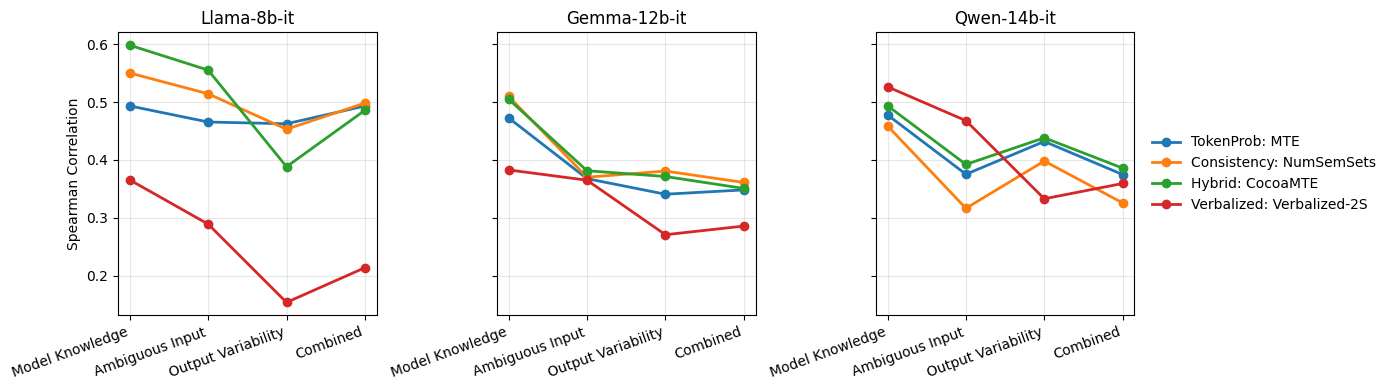

In [24]:
import numpy as np
import matplotlib.pyplot as plt

types = ["single", "single_ambi", "multi", "combined"]
type_labels = ["Model Knowledge", "Ambiguous Input", "Output Variability", "Combined"]
models = ["llama8bit", "gemma12bit", "qwen14bit"]
model_pretty = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen14bit": "Qwen-14b-it",
}

x = np.arange(len(types))

fig, axes = plt.subplots(1, len(models), figsize=(14, 4), sharey=True)

for ax, m in zip(axes, models):
    per_model = combined.xs(m, axis=1, level=0).reindex(columns=types)

    for group, metric in best_metrics_per_model[m].items():
        y = per_model.loc[metric, types]

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=f"{group}: {metric_pretty_name.get(metric, metric)}",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(type_labels, rotation=20, ha="right")
    ax.set_title(model_pretty.get(m, m))
    ax.grid(alpha=0.3)

    if ax is axes[0]:
        ax.set_ylabel("Spearman Correlation")

axes[-1].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

# plt.suptitle("Best Method per Family, Separately for Each Model", y=1.05)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = ["llama8bit", "gemma12bit", "qwen14bit"]
types = ["single", "single_ambi", "multi", "combined"]

# Convert MultiIndex columns → long format
long = (
    combined
    .stack(level=0)   # model
    .stack(level=0)   # type
    .reset_index()
)

long.columns = ["method", "model", "type", "spearman"]

# keep order
long["type"] = pd.Categorical(long["type"], types, ordered=True)


NameError: name 'combined' is not defined

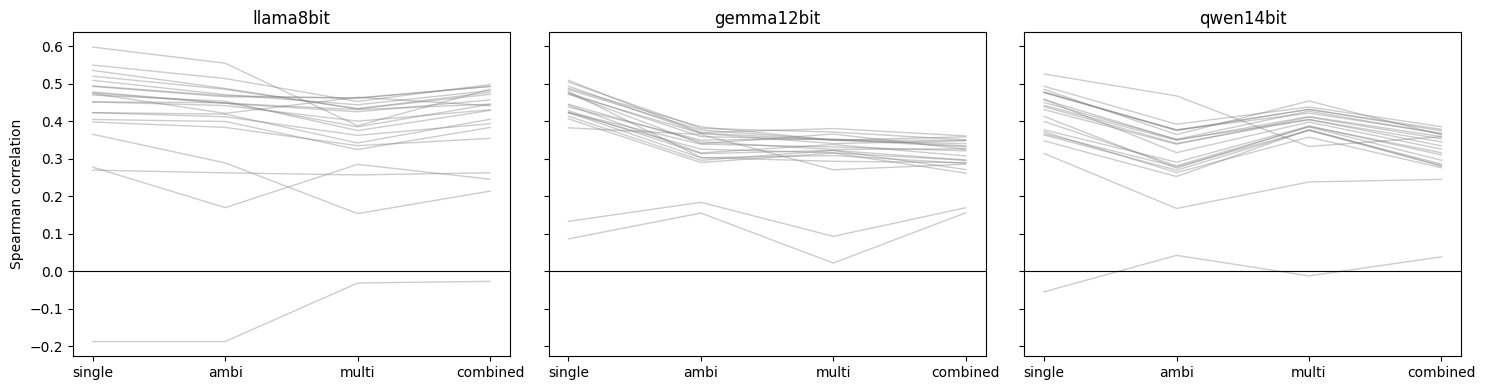

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

x = np.arange(len(types))

for ax, model in zip(axes, models):
    sub = long[long["model"] == model]

    for method, g in sub.groupby("method"):
        g = g.sort_values("type")

        # skip incomplete rows
        if g["spearman"].isna().any():
            continue

        ax.plot(
            x,
            g["spearman"],
            color="gray",
            alpha=0.4,
            linewidth=1
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["single", "ambi", "multi", "combined"])
    ax.set_title(model)
    ax.axhline(0, color="black", linewidth=0.8)

axes[0].set_ylabel("Spearman correlation")
plt.tight_layout()
plt.show()


In [61]:
baseline = (
    long[long["type"] == "single"]
    .set_index(["method", "model"])["spearman"]
)

long["delta"] = long.apply(
    lambda r: r["spearman"] - baseline.loc[(r["method"], r["model"])],
    axis=1
)


In [63]:
# Average across models
avg = (
    combined
    .groupby(level=1, axis=1)  # group by type (single, ambi, ...)
    .mean()
)

# Ensure correct column order
types = ["single", "single_ambi", "multi", "combined"]
avg = avg[types]


/tmp/ipykernel_1314561/2265886713.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  combined


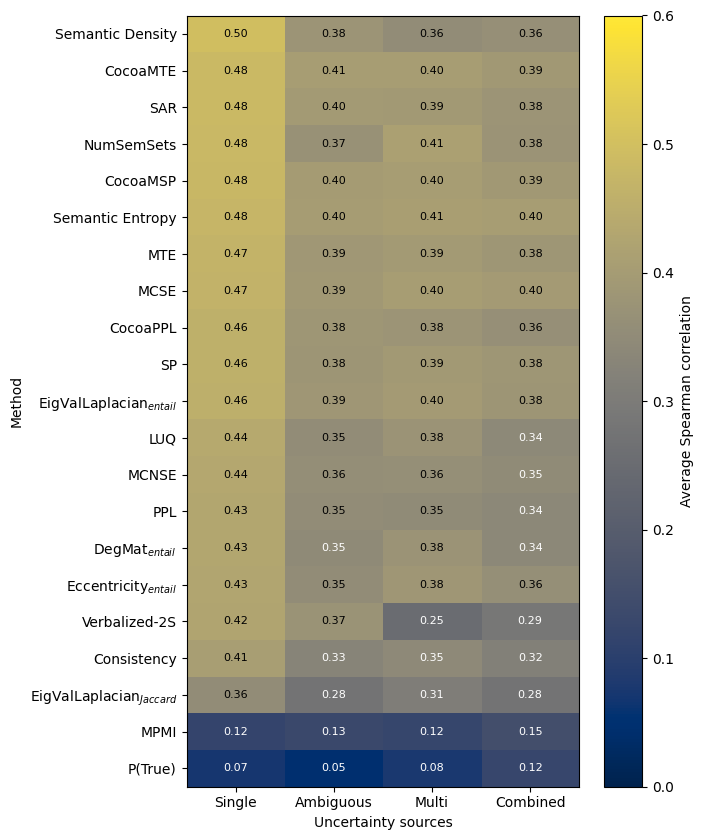

In [65]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 8.5))

im = ax.imshow(
    avg.values,
    aspect="auto",
    cmap="cividis",
    vmin=0.0,
    vmax=0.6
)

# Axis ticks
ax.set_xticks(np.arange(len(types)))
ax.set_xticklabels(["Single", "Ambiguous", "Multi", "Combined"])

ax.set_yticks(np.arange(len(avg.index)))
ax.set_yticklabels([metric_pretty_name[m] for m in avg.index])

ax.set_xlabel("Uncertainty sources")
ax.set_ylabel("Method")

# Annotate numbers
for i in range(avg.shape[0]):
    for j in range(avg.shape[1]):
        val = avg.iloc[i, j]
        if not np.isnan(val):
            ax.text(
                j, i, f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if val < 0.35 else "black"
            )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Average Spearman correlation")

plt.tight_layout()
plt.show()

